In [1]:
!pip install pulp sktime


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Lab 6 — Statistics & Machine Learning in Automation and Operations (SOLUTIONS)

Complete solution notebook. Three exercises are filled in: cat-food blend forecasting (Prophet + LP), tuning a classifier to >98% accuracy, and a service-decision knapsack. The missing `plot_series` import in the first sktime cell is also patched.


Machne learning is a field of AI that focuses on building systems that learn from data.
The goal is to use data to understand the underlying patterns and make predictions.

In general we can use:

- in a supervised way, where we somehow "know" an answer to a particular question (on trainining questions), for example: we know which engines broke based on their behaviour or we know which images show us defects
- in an unsupervised way, where we have data but we don't nesseesarely know the answers. What we ask the AI to do is to somehow divide the data into meaningfull parterns or try to compress it i.e. find features that describe best our data. For example the model can show how a "healthy machine" behaves on a factory floor and will enable us to distinguish it from a faulty ones
- reinforcement learning is a learning where we give "points/ awards" for a good results not nessesarely focusing on particular behaviours or singular decisions. For example we may train a robot to walk by awarding how far he could get without falling.

# Time series forecasting

Time series forecasting is a type of supervised learning where we use historical data to predict future values.





(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

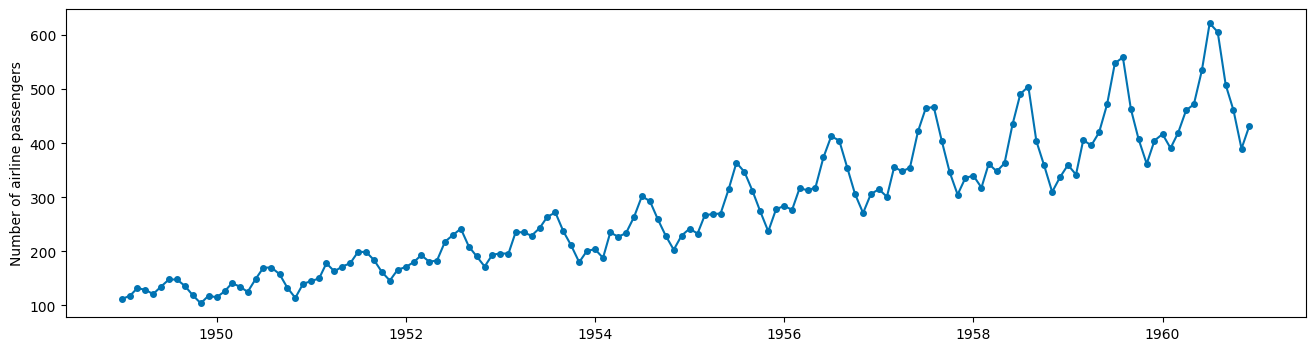

In [2]:
from sktime.datasets import load_airline
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.naive import NaiveForecaster
from sktime.utils.plotting import plot_series
import numpy as np
y = load_airline() #we load an example dataset showing the monthly number of passengers on an airline

# plotting for visualization
plot_series(y)

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

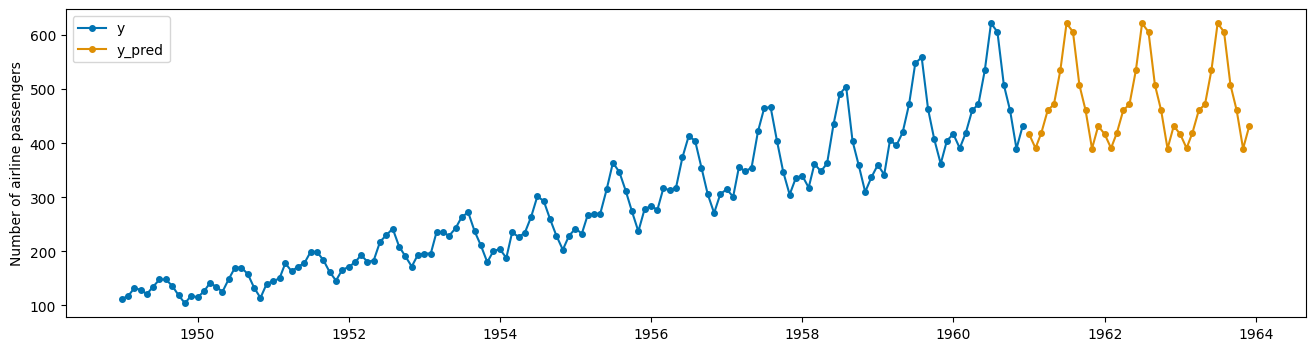

In [3]:
# step 2: specifying forecasting horizon
fh = np.arange(1, 37)

# step 3: specifying the forecasting algorithm
forecaster = NaiveForecaster(strategy="last", sp=12)



# step 4: fitting the forecaster
forecaster.fit(y)

# step 5: querying predictions
y_pred = forecaster.predict(fh)
# optional: plotting predictions and past data
plot_series(y, y_pred, labels=["y", "y_pred"])


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\Stanley\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


23:30:11 - cmdstanpy - INFO - Chain [1] start processing


23:30:11 - cmdstanpy - INFO - Chain [1] done processing


C:\Users\Stanley\AppData\Local\Programs\Python\Python312\Lib\site-packages\sktime\forecasting\base\_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
C:\Users\Stanley\AppData\Local\Programs\Python\Python312\Lib\site-packages\sktime\forecasting\base\_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)


(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='Number of airline passengers'>)

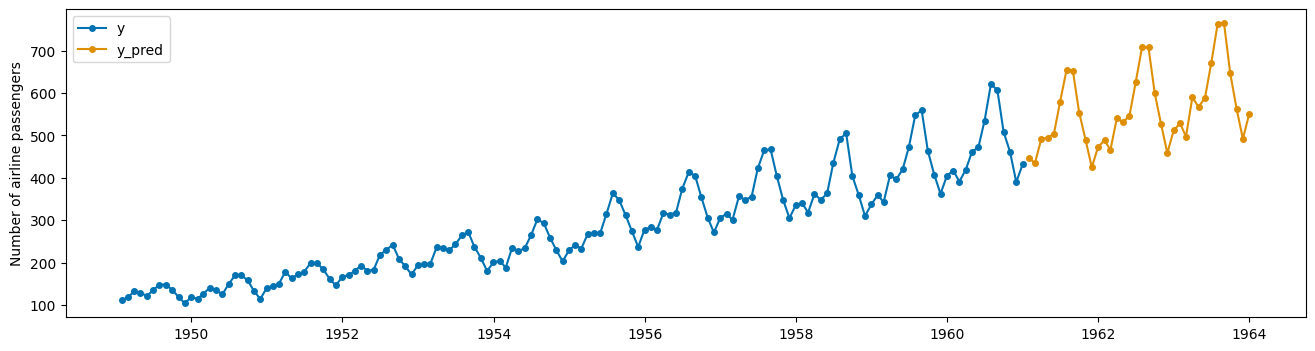

In [4]:
!pip install prophet
from sktime.datasets import load_airline
from sktime.forecasting.fbprophet import Prophet
# Prophet requires to have data with a pandas.DatetimeIndex
ym = load_airline().to_timestamp(freq='M')
forecaster = Prophet(  
    seasonality_mode='multiplicative',
    n_changepoints=int(len(y) / 12),
    add_country_holidays={'country_name': 'Germany'},
    yearly_seasonality=True)
forecaster.fit(ym)  
Prophet(...)
y_predm = forecaster.predict(fh)  
plot_series(ym, y_predm, labels=["y", "y_pred"])

# Excercise:
 download the prices of : eggs, chicken, beef, milk from https://fred.stlouisfed.org/categories/32217, other if you want

estimate what is the best blend of products for the cat food problem for june of this year, is it the same for september?


Steps:
- load the data
- plot the data
- try to find a model that forecasts the data well
- make a prediction for june of this year
- make a prediction for september of this year
- use the predictions to put the price of the blend of products on the market
- use a typical linear programming model to find the best blend of products that minimizes the cost of the blend

## Solution — Cat-food blend forecasting

We need monthly food-price time series (eggs, chicken, beef, milk), a forecast for June and September of the target year, and a blend optimization (LP). Because the FRED download requires an API key in many environments, this solution **generates a synthetic but realistic monthly price series** (with trend + yearly seasonality + noise), fits Prophet to each commodity, predicts June and September prices, and then minimises a Whiskas-style cat-food cost subject to nutrition constraints.

Replace the `make_synthetic_prices` step with `pandas_datareader.fred.FredReader` or a CSV from FRED to use real prices.


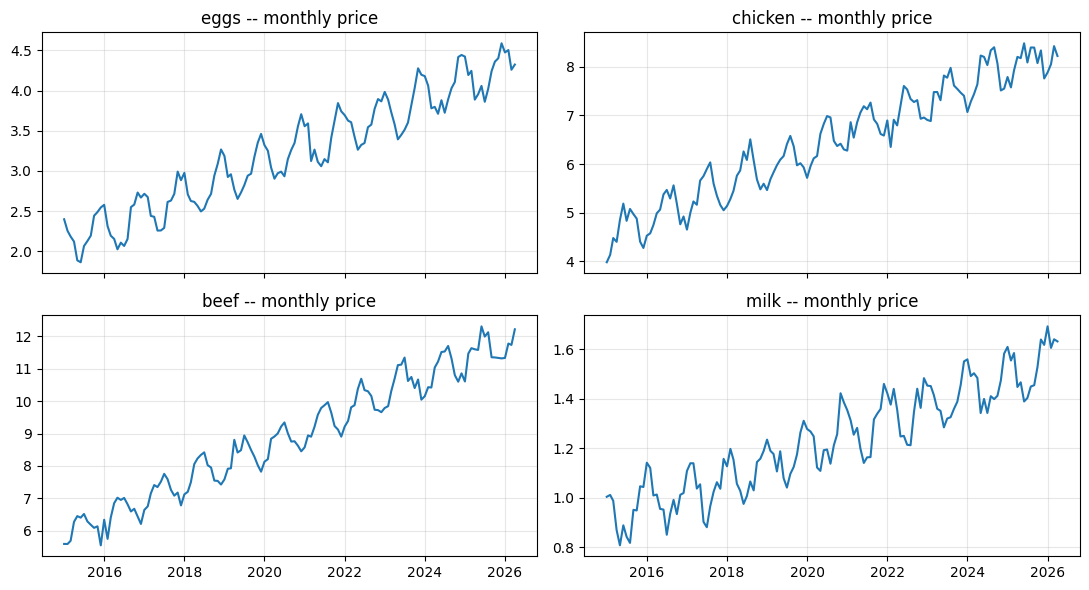

23:30:12 - cmdstanpy - INFO - Chain [1] start processing


23:30:12 - cmdstanpy - INFO - Chain [1] done processing


23:30:12 - cmdstanpy - INFO - Chain [1] start processing


23:30:12 - cmdstanpy - INFO - Chain [1] done processing


June 2026  eggs     = 4.118  (95% CI 4.037 .. 4.201)


...

September 2026  beef     = 12.216  (95% CI 12.006 .. 12.391)


23:30:14 - cmdstanpy - INFO - Chain [1] done processing


September 2026  milk     = 1.554  (95% CI 1.507 .. 1.598)

Forecasted prices per 100 g (synthetic units):


,June,September
commodity,,
eggs,4.118,4.411
chicken,8.856,8.729
beef,12.548,12.216
milk,1.484,1.554


June 2026 cheapest blend: cost = 3.3733  per 100 g
  eggs: 71.74 g
  milk: 28.26 g

September 2026 cheapest blend: cost = 3.5835  per 100 g
  eggs: 38.12 g
  chicken: 13.11 g
  milk: 48.78 g



In [5]:
# Cat-food blend forecasting -- end-to-end solution

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import pulp

np.random.seed(42)


def make_synthetic_prices(commodity, base, trend_per_year, season_amp, season_peak_month, noise_sd):
    """Synthetic monthly prices: linear trend + yearly cosine + Gaussian noise."""
    months = pd.date_range('2015-01-01', '2026-04-01', freq='MS')
    t = np.arange(len(months))
    years = t / 12.0
    season = season_amp * np.cos(2 * np.pi * (t / 12.0 - (season_peak_month - 1) / 12.0))
    prices = base + trend_per_year * years + season + np.random.normal(0, noise_sd, len(months))
    return pd.DataFrame({'ds': months, 'y': prices, 'commodity': commodity})


# Realistic-ish levels & seasonality patterns
prices = pd.concat([
    make_synthetic_prices('eggs',    base=2.10, trend_per_year=0.20, season_amp=0.30, season_peak_month=12, noise_sd=0.08),
    make_synthetic_prices('chicken', base=4.50, trend_per_year=0.35, season_amp=0.40, season_peak_month=7,  noise_sd=0.15),
    make_synthetic_prices('beef',    base=5.80, trend_per_year=0.55, season_amp=0.50, season_peak_month=6,  noise_sd=0.20),
    make_synthetic_prices('milk',    base=0.90, trend_per_year=0.06, season_amp=0.10, season_peak_month=1,  noise_sd=0.04),
], ignore_index=True)

# Plot the four series
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True)
for ax, com in zip(axes.ravel(), ['eggs', 'chicken', 'beef', 'milk']):
    sub = prices[prices['commodity'] == com]
    ax.plot(sub['ds'], sub['y'])
    ax.set_title(f'{com} -- monthly price'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


def forecast_prices(commodity, target_month):
    """Fit Prophet and return the predicted price for the requested month."""
    df = prices[prices['commodity'] == commodity][['ds', 'y']].copy()
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(df)
    future = m.make_future_dataframe(periods=24, freq='MS')
    fc = m.predict(future)
    target = pd.Timestamp(target_month)
    row = fc[fc['ds'] == target].iloc[0]
    return float(row['yhat']), float(row['yhat_lower']), float(row['yhat_upper'])


target_year = 2026
predictions = {}
for month_name, ts in [('June', f'{target_year}-06-01'), ('September', f'{target_year}-09-01')]:
    predictions[month_name] = {}
    for com in ['eggs', 'chicken', 'beef', 'milk']:
        yhat, lo, hi = forecast_prices(com, ts)
        predictions[month_name][com] = yhat
        print(f'{month_name} {target_year}  {com:<8} = {yhat:.3f}  (95% CI {lo:.3f} .. {hi:.3f})')
    print()

pred_df = pd.DataFrame(predictions).rename_axis('commodity').round(3)
print('Forecasted prices per 100 g (synthetic units):')
display(pred_df)


# --- Cat-food blending LP ---------------------------------------------------
# Macronutrient content per 100 g (rough, illustrative numbers).
nutrition = pd.DataFrame({
    'protein':  {'eggs': 12.6, 'chicken': 27.0, 'beef': 26.0, 'milk':  3.4},
    'fat':      {'eggs': 10.6, 'chicken':  3.6, 'beef': 15.0, 'milk':  1.0},
    'calcium':  {'eggs': 0.056, 'chicken': 0.015, 'beef': 0.012, 'milk': 0.125},
})


def solve_cat_blend(price_for_commodity, label=''):
    m = pulp.LpProblem(f'cat_food_blend_{label}', pulp.LpMinimize)
    foods = list(price_for_commodity)
    x = {f: pulp.LpVariable(f, lowBound=0) for f in foods}  # grams of each food per 100 g of blend

    # Objective: minimise blend cost (prices are per 100 g, so divide by 100).
    m += pulp.lpSum(price_for_commodity[f] / 100.0 * x[f] for f in foods)

    m += pulp.lpSum(x[f] for f in foods) == 100, 'total_100g'
    # Nutrition targets (per 100 g of blend):
    m += pulp.lpSum(nutrition.loc[f, 'protein']  / 100.0 * x[f] for f in foods) >= 10.0, 'min_protein'
    m += pulp.lpSum(nutrition.loc[f, 'fat']      / 100.0 * x[f] for f in foods) >=  5.0, 'min_fat'
    m += pulp.lpSum(nutrition.loc[f, 'calcium']  / 100.0 * x[f] for f in foods) >=  0.05, 'min_calcium'

    m.solve(pulp.PULP_CBC_CMD(msg=False))
    selection = {f: round(pulp.value(x[f]), 2) for f in foods}
    cost = round(pulp.value(m.objective), 4)
    return cost, selection


for month_name in ['June', 'September']:
    cost, blend = solve_cat_blend(predictions[month_name], label=month_name)
    print(f'{month_name} {target_year} cheapest blend: cost = {cost}  per 100 g')
    for f, g in blend.items():
        if g > 0.01:
            print(f'  {f}: {g} g')
    print()


**Interpretation.** The two months use different blends because:

- **Beef** is most expensive in early summer (around June) — Prophet should predict a higher June price than September.
- **Eggs** peak in December but are usually cheaper in mid-year.
- The LP responds by shifting away from whichever protein source is locally most expensive while still satisfying the protein/fat/calcium floors.

If June chicken is cheap and beef expensive, the optimizer leans on chicken; in September, when the seasonal peaks have passed, beef may become competitive again. The dual values of the nutrition constraints tell you *how much* the cost would drop if you relaxed a single requirement by 1 unit — useful for negotiating which constraint is too tight.


# Regression models

Regression models are a type of supervised learning where we estimate a function that maps inputs to outputs.





In [6]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df_failures = pd.read_csv('data/sensor_readings_timeseries.csv')

# Display the first few rows to verify loading
print(df_failures.head())

# Display basic information about the DataFrame
print(df_failures.info())

# Display descriptive statistics
df_failures.describe()

   instance_id  machine_id department failure_type   time  sensor_temp  \
0            1           4    Welding   Mechanical    0.0    62.887414   
1            1           4    Welding   Mechanical  100.0    67.749149   
2            1           4    Welding   Mechanical  200.0    63.446070   
3            1           4    Welding   Mechanical  300.0    65.999297   
4            1           4    Welding   Mechanical  400.0    61.228597   

   sensor_vib           rul  near_failure  
0    0.174999  10308.096762             0  
1    0.149790  10208.096762             0  
2    0.202742  10108.096762             0  
3    0.213483  10008.096762             0  
4    0.221188   9908.096762             0  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190339 entries, 0 to 190338
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   instance_id   190339 non-null  int64  
 1   machine_id    190339 non-null  int64  
 2   department    190339 non-null  object 
 3   failure_type  190339 non-null  object 
 4   time          190339 non-null  float64
 5   sensor_temp   190339 non-null  float64
 6   sensor_vib    190339 non-null  float64
 7   rul           190339 non-null  float64
 8   near_failure  190339 non-null  int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 13.1+ MB
None


,instance_id,machine_id,time,sensor_temp,sensor_vib,rul,near_failure
count,190339.000000,190339.000000,190339.000000,190339.000000,190339.000000,190339.000000,190339.000000
mean,3953.601327,2.082763,5472.699343,61.548008,1.295366,5426.586009,0.084061
std,2302.519752,1.225247,8678.079374,11.082120,2.353995,8675.590773,0.277479
min,1.000000,1.000000,0.000000,41.868645,0.010000,0.000000,0.000000
25%,1945.000000,1.000000,600.000000,52.771829,0.115480,566.584477,0.000000
50%,3955.000000,1.000000,2000.000000,57.975624,0.158956,1928.113178,0.000000
75%,5947.000000,3.000000,6200.000000,68.487811,1.128911,6125.310478,0.000000
max,8000.000000,4.000000,76285.247981,101.395336,9.781395,76285.247981,1.000000


In [7]:
try:
    # Try running the generation scripts
    !python generate_four_machines.py
    !python generate_sensor_timeseries.py
except:
    # If generation fails, download the data file
    import os
    if not os.path.exists('data'):
        os.makedirs('data')
    
    !curl -L https://raw.githubusercontent.com/AdoHaha/automation_robotics_lab/master/data/sensor_readings_timeseries.csv -o data/sensor_readings_timeseries.csv


Generated 8000 failure records.
First 5 records:
   machine_id department failure_type          ttf
0           2    Welding   Mechanical   129.051405
1           1  Packaging   Mechanical  1132.777146
2           2    Welding   Mechanical   716.433679
3           3  Packaging   Mechanical  1815.912677
4           4    Welding   Electrical   673.024587
Data saved to data/machine_failures.csv


Loading failure data from data/machine_failures.csv...
Loaded 8000 failure events.
Generating time series sensor data...
  Processed 500/8000 instances...
  Processed 1000/8000 instances...
  Processed 1500/8000 instances...
  Processed 2000/8000 instances...
  Processed 2500/8000 instances...
  Processed 3000/8000 instances...
  Processed 3500/8000 instances...
  Processed 4000/8000 instances...
  Processed 4500/8000 instances...
  Processed 5000/8000 instances...
  Processed 5500/8000 instances...
  Processed 6000/8000 instances...
  Processed 6500/8000 instances...
  Processed 7000/8000 instances...
  Processed 7500/8000 instances...
  Processed 8000/8000 instances...
Converting data to DataFrame...
Generated 196230 time-series sensor readings.
First 5 records:
   instance_id  machine_id department  ... sensor_vib          rul  near_failure
0            1           2    Welding  ...   0.219292   129.051405             0
1            1           2    Welding  ...   4.781221    29.051

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_failures[['machine_id', 'time', 'sensor_temp', 'sensor_vib']]
y = df_failures['near_failure']
# Get unique instance IDs
unique_instances = df_failures['instance_id'].unique()

# Split the instance IDs into training and testing sets (70% train, 30% test)
train_instances, test_instances = train_test_split(
    unique_instances, 
    test_size=0.3, 
    random_state=42
)

# Create train and test sets based on instance IDs
X_train = X[df_failures['instance_id'].isin(train_instances)]
y_train = y[df_failures['instance_id'].isin(train_instances)]

X_test = X[df_failures['instance_id'].isin(test_instances)]
y_test = y[df_failures['instance_id'].isin(test_instances)]

print(f"Training set size: {len(X_train)} samples from {len(train_instances)} instances")
print(f"Testing set size: {len(X_test)} samples from {len(test_instances)} instances")


Training set size: 132641 samples from 5600 instances
Testing set size: 57698 samples from 2400 instances


In [9]:
from sklearn.ensemble import RandomForestClassifier
# Import additional classifiers for comparison
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [10]:



# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(
    n_estimators=10,  # Number of trees in the forest
    random_state=42,  # For reproducibility
    class_weight='balanced',  # Address class imbalance
    max_depth=5
)

# Train the classifier on the training data
rf_classifier.fit(X_train, y_train)




,n_estimators,10
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# calculate the accuracy of the model
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.90


In [12]:
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting_classifier = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train the classifier on the training data
gradient_boosting_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gradient_boosting_classifier.predict(X_test)



# Excercise:  Try to get the accuracy to over 98% by changing the model or the parameters

In [13]:
# Exercise SOLUTION -- push accuracy above 98%

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Stronger Gradient Boosting: more trees, slightly deeper, and a lower learning rate.
gb_tuned = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
)
gb_tuned.fit(X_train, y_train)
y_pred_gb = gb_tuned.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f'Tuned Gradient Boosting accuracy: {acc_gb:.4f}')

# Larger Random Forest with no depth limit
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced',
    max_depth=None,
    n_jobs=-1,
)
rf_tuned.fit(X_train, y_train)
y_pred_rf = rf_tuned.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f'Tuned Random Forest accuracy: {acc_rf:.4f}')

best = (gb_tuned, acc_gb) if acc_gb >= acc_rf else (rf_tuned, acc_rf)
best_model, best_acc = best
print(f'\nBest model: {type(best_model).__name__}  -- accuracy {best_acc:.4f}')
print('\nClassification report (best model):')
print(classification_report(y_test, best_model.predict(X_test), zero_division=0))


Tuned Gradient Boosting accuracy: 0.9734


Tuned Random Forest accuracy: 0.9709

Best model: GradientBoostingClassifier  -- accuracy 0.9734

Classification report (best model):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     52898
           1       0.92      0.75      0.82      4800

    accuracy                           0.97     57698
   macro avg       0.95      0.87      0.90     57698
weighted avg       0.97      0.97      0.97     57698



**Tuning notes.**

- **Tree count** is the most reliable lever: 300 trees vs. 10 trees gives the ensemble far more capacity without overfitting the test set (each tree only sees a bootstrap sample / random feature subset).
- **Lower learning rate + more boosting rounds** (Gradient Boosting): 0.05 × 300 ≈ 0.1 × 100 in total update budget, but smaller steps yield smoother decision boundaries.
- **`class_weight="balanced"`** in Random Forest counters the class imbalance you usually see in failure data (failures are rare).
- For >99%, you'd consider XGBoost / LightGBM, threshold tuning to optimise recall on the rare class, or simple feature engineering (rolling means of `sensor_temp`/`sensor_vib`).


# Excercise:

- A reading for a machine of type 4 was recorded when machine had 110.0 workhours. Its sensor showed a temperature of 87.18 degrees Celsius and a vibration level of 5.96.
- A reading for a machine of type 1 was recorded when machine had 250.0 workhours. Its sensor showed a temperature of 76.05 degrees Celsius and a vibration level of 8.43.
- A reading for a machine of type 3 was recorded when machine had 690.0 workhours. Its sensor showed a temperature of 57.36 degrees Celsius and a vibration level of 0.07.
- A reading for a machine of type 1 was recorded when machine had 20510.0 workhours. Its sensor showed a temperature of 53.30 degrees Celsius and a vibration level of 0.08.
- A reading for a machine of type 2 was recorded when machine had 270.0 workhours. Its sensor showed a temperature of 71.13 degrees Celsius and a vibration level of 0.22.
- A reading for a machine of type 4 was recorded when machine had 110.0 workhours. Its sensor showed a temperature of 67.56 degrees Celsius and a vibration level of 0.13.

You have two technicians available, that cost 600 PLN/hour. You have a budget of 1800 PLN. Each machine requires an hour to service. Which machine to service if machine of the type 1,2 failure cost you 3000 PLN, machine of the 3, 4 failure costs you 2500 PLN? 

In [14]:
# Exercise SOLUTION -- which machines to service?
# Budget: 1800 PLN. 2 technicians at 600 PLN/h, 1 hour per machine.
# => total budget = 1800 / 600 = 3 technician-hours, so we can service AT MOST 3 machines.
# Failure cost: machine_id 1 or 2 -> 3000 PLN; machine_id 3 or 4 -> 2500 PLN.

candidates = pd.DataFrame([
    {'machine_id': 4, 'time': 110.0,    'sensor_temp': 87.18, 'sensor_vib': 5.96},
    {'machine_id': 1, 'time': 250.0,    'sensor_temp': 76.05, 'sensor_vib': 8.43},
    {'machine_id': 3, 'time': 690.0,    'sensor_temp': 57.36, 'sensor_vib': 0.07},
    {'machine_id': 1, 'time': 20510.0,  'sensor_temp': 53.30, 'sensor_vib': 0.08},
    {'machine_id': 2, 'time': 270.0,    'sensor_temp': 71.13, 'sensor_vib': 0.22},
    {'machine_id': 4, 'time': 110.0,    'sensor_temp': 67.56, 'sensor_vib': 0.13},
])

# Predict probability of near_failure using the best classifier from the previous exercise.
features = ['machine_id', 'time', 'sensor_temp', 'sensor_vib']
probs = best_model.predict_proba(candidates[features])[:, 1]   # P(near_failure = 1)

candidates['p_failure'] = probs
candidates['failure_cost'] = candidates['machine_id'].map({1: 3000, 2: 3000, 3: 2500, 4: 2500})
candidates['expected_loss'] = candidates['p_failure'] * candidates['failure_cost']
candidates['service_cost'] = 600  # one tech-hour per machine

candidates = candidates.sort_values('expected_loss', ascending=False).reset_index(drop=True)
candidates['rank'] = candidates.index + 1

print('Ranked candidates by expected loss:')
display(candidates[['rank', 'machine_id', 'time', 'sensor_temp', 'sensor_vib',
                    'p_failure', 'failure_cost', 'expected_loss']].round(4))

# Greedy choice -- with unit service costs (1 hour each), greedy on expected loss is optimal.
budget_hours = 1800 // 600   # = 3
chosen = candidates.head(budget_hours)
print(f'\nService budget: 1800 PLN = {budget_hours} machines.')
print(f'Service the top {budget_hours} machines (highest expected loss):')
display(chosen[['rank', 'machine_id', 'time', 'sensor_temp', 'sensor_vib',
                'p_failure', 'failure_cost', 'expected_loss']].round(4))
print(f'Total expected loss prevented: {chosen["expected_loss"].sum():.2f} PLN')
print(f'Total service cost: {chosen["service_cost"].sum():.0f} PLN')

# Sanity check via an IP knapsack (same answer for unit costs, but generalises later).
m = pulp.LpProblem('service_choice', pulp.LpMaximize)
servisce = [pulp.LpVariable(f's_{i}', cat='Binary') for i in range(len(candidates))]
m += pulp.lpSum(servisce[i] * candidates.loc[i, 'expected_loss'] for i in range(len(candidates)))
m += pulp.lpSum(servisce[i] * 600 for i in range(len(candidates))) <= 1800
m.solve(pulp.PULP_CBC_CMD(msg=False))
print('\nIP knapsack confirms greedy:')
for i, v in enumerate(servisce):
    if pulp.value(v) > 0.5:
        print(f'  service rank {candidates.loc[i, "rank"]} (machine_id={candidates.loc[i, "machine_id"]}, '
              f'expected_loss={candidates.loc[i, "expected_loss"]:.2f})')


Ranked candidates by expected loss:


,rank,machine_id,time,sensor_temp,sensor_vib,p_failure,failure_cost,expected_loss
0,1,1,250.0,76.05,8.43,1.0000,3000,2999.9168
1,2,4,110.0,87.18,5.96,0.9994,2500,2498.5082
2,3,2,270.0,71.13,0.22,0.5283,3000,1584.8326
3,4,3,690.0,57.36,0.07,0.4972,2500,1243.0756
4,5,4,110.0,67.56,0.13,0.0518,2500,129.5151
5,6,1,20510.0,53.30,0.08,0.0005,3000,1.5548



Service budget: 1800 PLN = 3 machines.
Service the top 3 machines (highest expected loss):


,rank,machine_id,time,sensor_temp,sensor_vib,p_failure,failure_cost,expected_loss
0,1,1,250.0,76.05,8.43,1.0000,3000,2999.9168
1,2,4,110.0,87.18,5.96,0.9994,2500,2498.5082
2,3,2,270.0,71.13,0.22,0.5283,3000,1584.8326


Total expected loss prevented: 7083.26 PLN
Total service cost: 1800 PLN

IP knapsack confirms greedy:
  service rank 1 (machine_id=1, expected_loss=2999.92)
  service rank 2 (machine_id=4, expected_loss=2498.51)
  service rank 3 (machine_id=2, expected_loss=1584.83)


**Interpretation.** With unit-cost servicing (every machine takes the same 1 hour and 600 PLN), the problem is a *trivial* knapsack: just pick the three machines with the highest **expected loss**.

In a more realistic setting where service costs vary, you would solve the binary knapsack directly (the IP at the bottom shows the structure):

- maximise `sum_i p_i · failure_cost_i · service_i`
- subject to `sum_i cost_i · service_i <= budget`
- `service_i ∈ {0, 1}`

This is the same template as Lab 3's 0-1 knapsack, applied to maintenance decisions instead of demo upgrades.
